In [24]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/108.7 kB ? eta -:--:--
     --- ------------------------------------ 10.2/108.7 kB ? eta -:--:--
     --- ------------------------------------ 10.2/108.7 kB ? eta -:--:--
     ------------- ----------------------- 41.0/108.7 kB 326.8 kB/s eta 0:00:01
     --------------------------------- -- 102.4/108.7 kB 535.8 kB/s eta 0:00:01
     ------------------------------------ 108.7/108.7 kB 523.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 0.1/7.8 MB ? eta -:--:--
   ---------------------------------------- 0.1/7.8 MB 1.7 MB/s eta 0:00:05
   - -------------------------------------- 0.2/7.8 MB 1.9 MB/s eta 0:00:05
   - -------------------------------------- 0.4/7.8 MB 2.1 MB/s eta 0:00:04
   -- ------------------------------------- 0.6/7.8 MB 2.6 MB/s eta 0:00:03
   ---- -------------------------

In [44]:
!pip install seaborn

   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 259.2 kB/s eta 0:00:02
   ---------- ---------------------------- 81.9/294.9 kB 573.4 kB/s eta 0:00:01
   ------------------------------- -------- 235.5/294.9 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.5 MB/s eta 0:00:00


In [54]:
!pip install xgboost

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB 131.3 kB/s eta 0:15:52
   ---------------------------------------- 0.0/124.9 MB 186.2 kB/s eta 0:11:11
   ---------------------------------------- 0.1/124.9 MB 326.8 kB/s eta 0:06:22
   ---------------------------------------- 0.1/124.9 MB 409.6 kB/s eta 0:05:05
   ---------------------------------------- 0.1/124.9 MB 435.7 kB/s eta 0:04:47
   ---------------------------------------- 0.2/124.9 MB 530.7 kB/s eta 0:03:56
   ---------------------------------------- 0.2/124.9 MB 576.2 kB/s eta 0:03:37
   ---------------------------------------- 0.3/124.9 MB 584.5 kB/s eta 0:03:34
   ---------------------------------------- 0.3/124.9 MB 611.3 kB/s eta 0:03:24
   ---------------------------------------- 0.3/124.9 MB 615.2 kB/s

In [25]:
import pandas as pd
import pickle
from sklearn.ensemble import RandomForestClassifier  # Example classifier, adjust as needed
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [26]:
df=pd.read_csv("Titanic-Dataset.csv")

In [27]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [28]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [34]:
# Define x
x = df.copy()

In [48]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['CabinLetter'] = df['Cabin'].str[0] 

In [49]:
# Feature engineering (example)
X = df[['Pclass', 'Age', 'SibSp', 'Parch']]  # Example features
y = df['Survived']
# Fill Age with median based on Pclass and Sex
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

In [30]:
X.isnull().sum()

Pclass    0
Age       0
SibSp     0
Parch     0
dtype: int64

In [31]:
import warnings
warnings.filterwarnings("ignore")

In [32]:
import matplotlib.pyplot as plt

In [33]:
median_income = df["Fare"].median()
print(median_income)

14.4542


In [35]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
gen=le.fit_transform(x.Sex)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 29)

In [37]:
len(X_train)

712

In [38]:
len(X_test)

179

In [39]:
# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [55]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = [
    RandomForestClassifier(),
    GradientBoostingClassifier(),
    XGBClassifier(use_label_encoder=False, eval_metric='logloss')
]

In [56]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10]
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5, 10],
                         'n_estimators': [50, 100, 200]})

In [57]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
print(scores.mean())

0.6869374176134582


In [60]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('feature_selection', SelectKBest(score_func=f_classif, k=10))
])

X_selected = pipeline.fit_transform(X, y)


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Train model
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6871508379888268


In [62]:
with open('titanic_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [63]:
import seaborn as sns


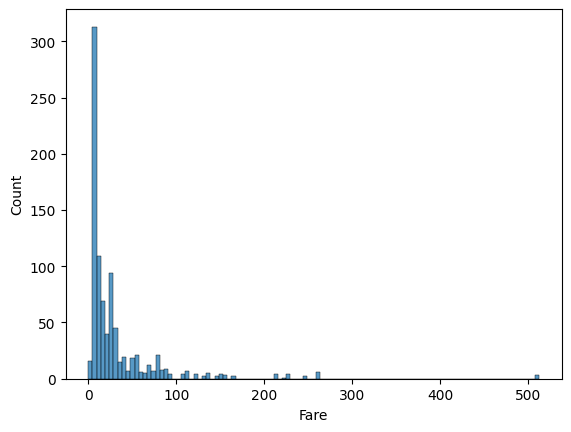

In [64]:
sns.histplot(data = df['Fare'])
plt.show()

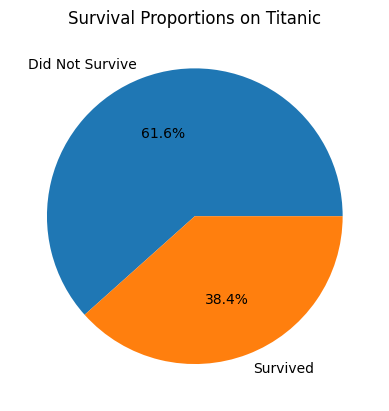

In [65]:
survival_counts = df['Survived'].value_counts()
plt.pie(survival_counts, labels= ['Did Not Survive', 'Survived'], autopct = '%1.1f%%')
plt.title('Survival Proportions on Titanic')
plt.show()